## 1. Data Preparation & Exploration

### 1.1 Required Libraries
First, we'll import all necessary libraries for our analysis.

In [21]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### 1.2 Data Import and Initial Exploration
Let's load our dataset and examine its basic properties:

In [22]:
# Read the dataset
df = pd.read_csv("Student_Performance.csv")

# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


### 1.3 Data Cleaning
We'll perform basic data cleaning steps:
1. Check and remove duplicates
2. Convert categorical variables to numeric format

In [23]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert categorical variables to numeric
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})

Number of duplicate rows: 127


### 1.4 Data Exploration
Let's analyze the relationships between variables using a correlation matrix heatmap:

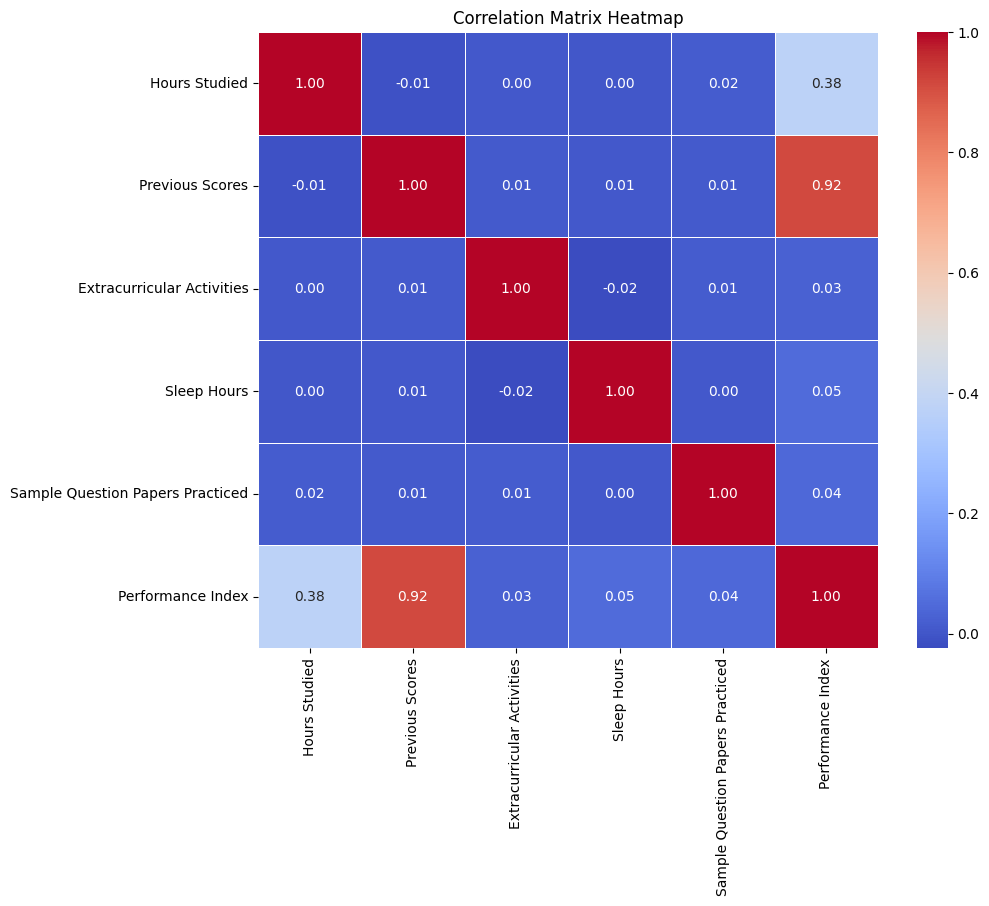

In [24]:
# Generate correlation matrix
corr_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

## 2. Model Implementation

### 2.1 Multiple Linear Regression Class
We'll implement a custom Multiple Linear Regression class that includes:
- Coefficient calculation using Normal Equation
- Model fitting and prediction
- Statistical measures (R², MSE, F-statistic)
- Visualization capabilities

In [25]:
class MultipleLinearRegression:
    def __init__(self):
        """
        Initializes the MultipleLinearRegression model.
        """
        self.coefficients = None
        self.intercept = None
        self._X_fit = None
        self._y_fit = None
        self._feature_names = None
        self.beta = None
        self.n = None
        self.p = None
        self.k = None
        self.y_bar = None
        self.SSR = None
        self.SSE = None
        self.SST = None
        self.SSR_df = None
        self.SSE_df = None
        self.SST_df = None
        self.MSR = None
        self.MSE = None
        self.r_squared = None
        self.F_stat = None
        self.F_p_value = None

    def fit(self, X, y):
        """
        Fits the multiple linear regression model using the Normal Equation.
        """
        if isinstance(X, pd.DataFrame):
            self._feature_names = X.columns.tolist()
        else:
            self._feature_names = [f'Feature {i+1}' for i in range(X.shape[1])]

        self.n = len(X)
        X_arr = np.asarray(X)
        y_arr = np.asarray(y)
        self.k = X_arr.shape[1]
        self.p = self.k + 1

        self._X_fit = X_arr
        self._y_fit = y_arr
        self.y_bar = np.mean(y_arr)

        X_b = np.c_[np.ones((X_arr.shape[0], 1)), X_arr]
        
        try:
            self.beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_arr
        except np.linalg.LinAlgError:
            self.beta = np.linalg.pinv(X_b) @ y_arr

        self.intercept = self.beta[0]
        self.coefficients = self.beta[1:]
        
        # Calculate statistics
        y_pred = self.predict(X_arr)
        self.SSE = np.sum((y_arr - y_pred) ** 2)
        self.SST = np.sum((y_arr - self.y_bar) ** 2)
        self.SSR = self.SST - self.SSE
        
        self.SSR_df = self.k
        self.SSE_df = self.n - self.p
        self.SST_df = self.n - 1
        
        self.MSR = self.SSR / self.SSR_df if self.SSR_df > 0 else np.nan
        self.MSE = self.SSE / self.SSE_df if self.SSE_df > 0 else np.nan
        
        if self.MSE is not None and not np.isnan(self.MSE) and self.MSE > 0:
            self.F_stat = self.MSR / self.MSE
            self.F_p_value = stats.f.sf(self.F_stat, self.SSR_df, self.SSE_df)
        
        self.r_squared = 1 - (self.SSE / self.SST) if self.SST != 0 else 0.0

    def predict(self, X):
        """
        Predicts target values for new data.
        """
        if self.coefficients is None:
            raise Exception("Model not fitted yet!")
            
        X_arr = np.asarray(X)
        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(1, -1)
            
        X_b = np.c_[np.ones((X_arr.shape[0], 1)), X_arr]
        return X_b @ self.beta

    def plot_3d(self):
        """
        Creates a 3D visualization of the regression plane.
        """
        if self._X_fit.shape[1] != 2:
            print("3D plot requires exactly 2 features.")
            return None
            
        feature1, feature2 = self._X_fit[:, 0], self._X_fit[:, 1]
        x_surf = np.linspace(feature1.min(), feature1.max(), 50)
        y_surf = np.linspace(feature2.min(), feature2.max(), 50)
        x_surf, y_surf = np.meshgrid(x_surf, y_surf)
        
        X_plane = np.c_[x_surf.ravel(), y_surf.ravel()]
        z_surf = self.predict(X_plane).reshape(x_surf.shape)

        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(feature1, feature2, self._y_fit, c='r', marker='o')
        ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5)
        
        ax.set_xlabel(self._feature_names[0])
        ax.set_ylabel(self._feature_names[1])
        ax.set_zlabel('Target Variable')
        ax.set_title('Multiple Linear Regression Plane')
        
        return fig, ax

## 3. Feature Selection & Model Building

### 3.1 Feature Selection
Based on the correlation analysis, we'll select the most influential features for our model:
- Previous Scores
- Hours Studied

In [26]:
# Select features and target variable
features = ['Previous Scores', 'Hours Studied']
X = df[features]
y = df['Performance Index']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
mlr = MultipleLinearRegression()
mlr.fit(X_train, y_train)

### 3.2 Model Visualization
Let's visualize our regression plane to understand how our model fits the data:

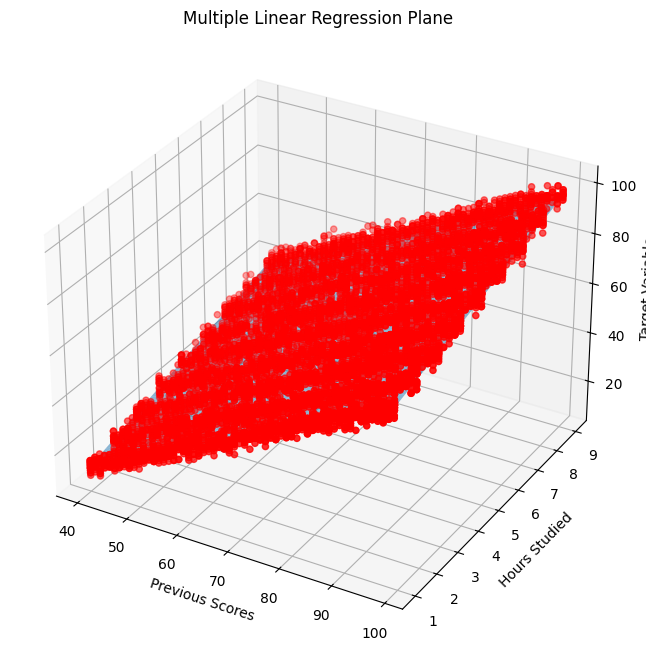

In [27]:
# Create 3D visualization of the regression plane
fig, ax = mlr.plot_3d()

## 4. Model Evaluation

### 4.1 Performance Metrics
Let's evaluate our model's performance using various metrics:
- R-squared (R²)
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate on test set
y_pred_test = mlr.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("=== Model Evaluation on Test Set ===")
print(f"R-squared (R²): {r2_test:.4f}")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")

=== Model Evaluation on Test Set ===
R-squared (R²): 0.9850
Mean Squared Error (MSE): 5.5738
Mean Absolute Error (MAE): 1.8798


## 5. Statistical Analysis

### 5.1 ANOVA and Hypothesis Testing
We'll perform statistical analysis to validate our model:
1. ANOVA (Analysis of Variance)
2. F-test for model significance
3. Confidence Intervals

In [29]:
# Create ANOVA table
anova_data = {
    'df': [mlr.SSR_df, mlr.SSE_df, mlr.SSR_df + mlr.SSE_df],
    'SS': [mlr.SSR, mlr.SSE, mlr.SSR + mlr.SSE],
    'MS': [mlr.MSR, mlr.MSE, np.nan],
    'F': [mlr.F_stat, np.nan, np.nan],
    'P-value': [mlr.F_p_value, np.nan, np.nan]
}

anova_df = pd.DataFrame(anova_data,
                       index=['Regression', 'Residual', 'Total'],
                       columns=['df', 'SS', 'MS', 'F', 'P-value'])

print("=== ANOVA Table ===")
print(anova_df.to_string(float_format="%.4f"))

# Hypothesis Test
alpha = 0.05
F_critical = stats.f.ppf(1 - alpha, mlr.SSR_df, mlr.SSE_df)

print("\n=== Hypothesis Test ===")
print(f"F-statistic: {mlr.F_stat:.4f}")
print(f"Critical F-value: {F_critical:.4f}")
print(f"p-value: {mlr.F_p_value:.4f}")
print(f"\nConclusion: {'Reject' if mlr.F_stat > F_critical else 'Fail to reject'} null hypothesis")

=== ANOVA Table ===
              df           SS           MS           F  P-value
Regression     2 2866120.4202 1433060.2101 277693.2746   0.0000
Residual    7895   40742.8317       5.1606         NaN      NaN
Total       7897 2906863.2520          NaN         NaN      NaN

=== Hypothesis Test ===
F-statistic: 277693.2746
Critical F-value: 2.9969
p-value: 0.0000

Conclusion: Reject null hypothesis
